In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

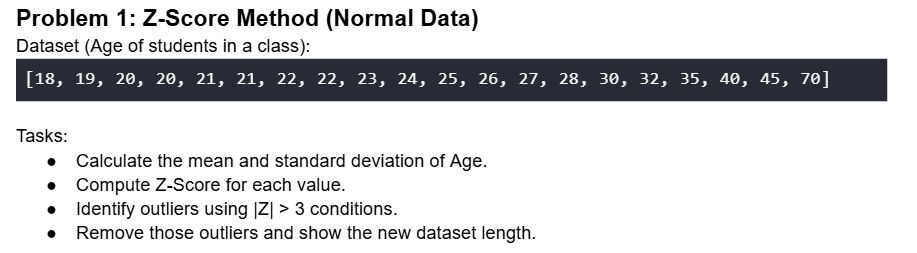

In [ ]:
age = np.array([18, 19, 20, 20, 21, 21, 22, 22, 23, 24,
                25, 26, 27, 28, 30, 32, 35, 40, 45, 70])
mean = np.mean(age)
std = np.std(age)


print("Mean:", mean)
print("Standard Deviation:", std)

Mean: 28.4
Standard Deviation: 11.825396399275586


In [3]:
z = (age - mean) / std
print(z)

[-0.87946312 -0.79489936 -0.7103356  -0.7103356  -0.62577183 -0.62577183
 -0.54120807 -0.54120807 -0.45664431 -0.37208055 -0.28751679 -0.20295303
 -0.11838927 -0.0338255   0.13530202  0.30442954  0.55812083  0.98093963
  1.40375844  3.51785248]


In [4]:
age_outliers = age[np.abs(z) > 3]
print("Outliers:", age_outliers)

Outliers: [70]


In [5]:
new_age = age[np.abs(z) <= 3]
print("New dataset:", new_age)
print("New length:", len(new_age))

New dataset: [18 19 20 20 21 21 22 22 23 24 25 26 27 28 30 32 35 40 45]
New length: 19


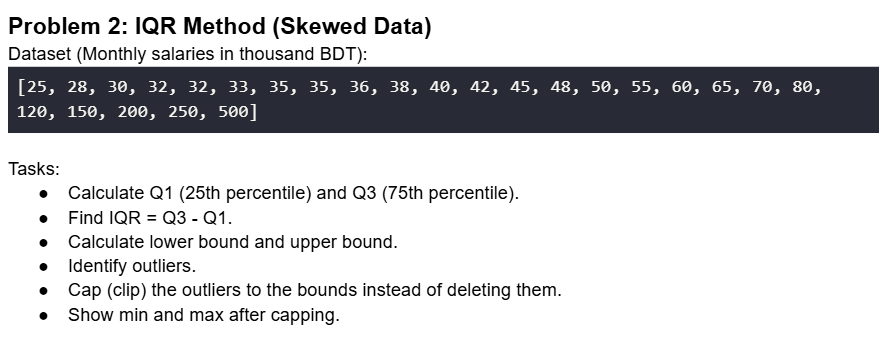

In [11]:
salary = pd.Series([
    25, 28, 30, 32, 32, 33, 35, 35, 36, 38,
    40, 42, 45, 48, 50, 55, 60, 65, 70, 80,
    120, 150, 200, 250, 500
])

# Q1 and Q3
Q1 = salary.quantile(0.25)
Q3 = salary.quantile(0.75)

# IQR
IQR = Q3 - Q1

# Lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)

# Find outliers
outliers = salary[(salary < lower) | (salary > upper)]

print("Outliers:")
print(outliers.values)

Q1 = 35.0
Q3 = 70.0
IQR = 35.0
Lower Bound = -17.5
Upper Bound = 122.5
Outliers:
[150 200 250 500]


In [8]:
salary_capped = salary.clip(lower, upper)
print("Min after capping:", salary_capped.min())
print("Max after capping:", salary_capped.max())

Min after capping: 25.0
Max after capping: 122.5


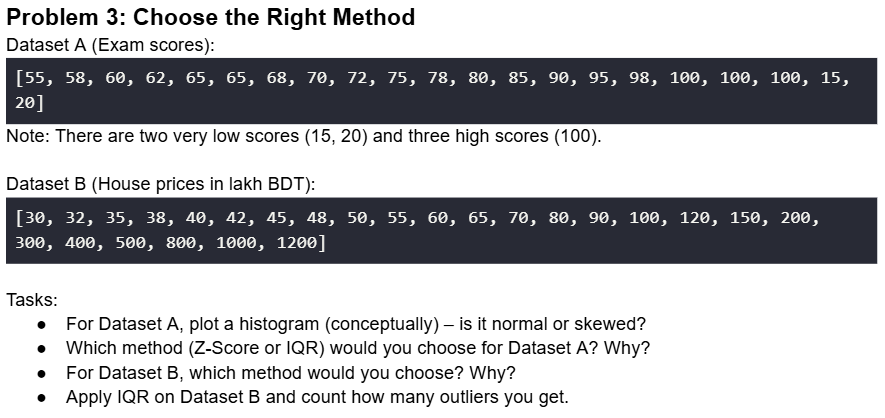

In [13]:
A = pd.Series([
    55, 58, 60, 62, 65, 65, 68, 70, 72, 75,
    78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20
])

B = pd.Series([
    30, 32, 35, 38, 40, 42, 45, 48, 50, 55,
    60, 65, 70, 80, 90, 100, 120, 150, 200, 300,
    400, 500, 800, 1000, 1200
])


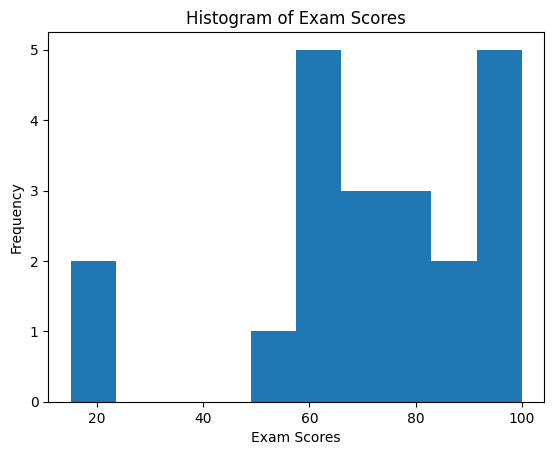

In [17]:
plt.hist(A)
plt.xlabel("Exam Scores")
plt.ylabel("Frequency")
plt.title("Histogram of Exam Scores")
plt.show()

Dataset A is skewed because of the very low values.The IQR method is more robust for skewed data and is less affected by extreme values

Also Dataset B contains very high values and the data is right skewed. so IQR is more suitable

In [18]:
Q1 = B.quantile(0.25)
Q3 = B.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = B[(B < lower) | (B > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)
print("Outliers =", outliers.values)
print("Number of outliers =", len(outliers))

Q1 = 45.0
Q3 = 200.0
IQR = 155.0
Lower Bound = -187.5
Upper Bound = 432.5
Outliers = [ 500  800 1000 1200]
Number of outliers = 4


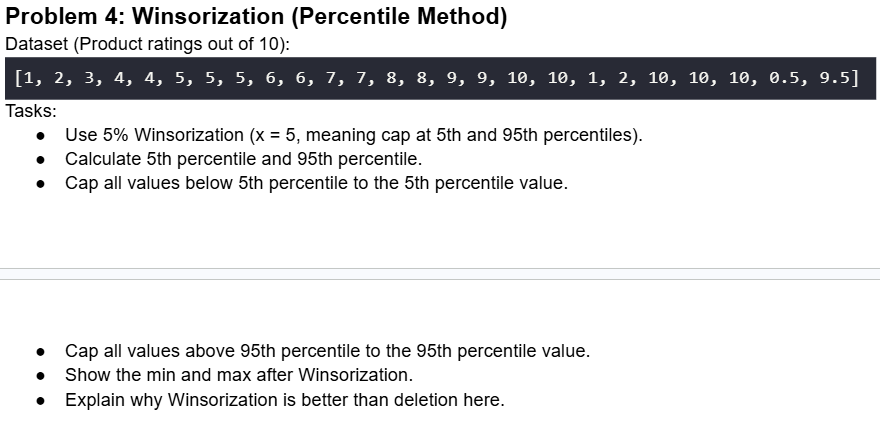

In [19]:
ratings = pd.Series([
    1, 2, 3, 4, 4, 5, 5, 5, 6, 6,
    7, 7, 8, 8, 9, 9, 10, 10, 1, 2,
    10, 10, 10, 0.5, 9.5
])

# 5th and 95th percentiles
lower = ratings.quantile(0.05)
upper = ratings.quantile(0.95)

print("5th Percentile =", lower)
print("95th Percentile =", upper)

# Winsorization / capping
winsorized = ratings.clip(lower=lower, upper=upper)

print("New Minimum =", winsorized.min())
print("New Maximum =", winsorized.max())

5th Percentile = 1.0
95th Percentile = 10.0
New Minimum = 1.0
New Maximum = 10.0


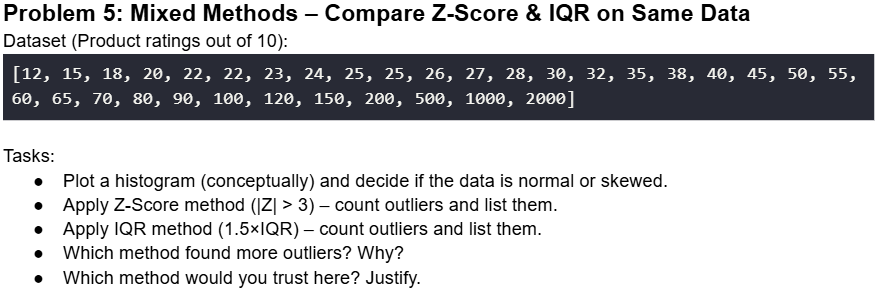

In [28]:
product_ratings = pd.Series([
    12, 15, 18, 20, 22, 22, 23, 24, 25, 25,
    26, 27, 28, 30, 32, 35, 38, 40, 45, 50,
    55, 60, 65, 70, 80, 90, 100, 120, 150, 200,
    500, 1000, 2000
])

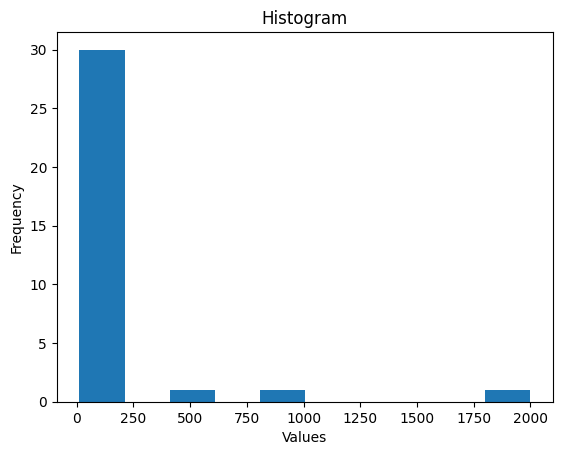

In [29]:
plt.hist(product_ratings)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

The data has very large values so it is right skewed

In [30]:
mean = product_ratings.mean()
std = product_ratings.std()

z = (product_ratings - mean) / std

z_outliers = product_ratings[abs(z) > 3]

print("Z-score outliers:")
print(z_outliers.values)
print("Number of outliers:", len(z_outliers))

Z-score outliers:
[2000]
Number of outliers: 1


In [31]:
Q1 = product_ratings.quantile(0.25)
Q3 = product_ratings.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = product_ratings[(product_ratings < lower) | (product_ratings > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)
print("IQR Outliers =", iqr_outliers.values)
print("Number of outliers =", len(iqr_outliers))

Q1 = 25.0
Q3 = 80.0
IQR = 55.0
Lower Bound = -57.5
Upper Bound = 162.5
IQR Outliers = [ 200  500 1000 2000]
Number of outliers = 4


The dataset is right-skewed. The very large values increase the mean and standard deviation, so the Z-score method does not identify some extreme values as outliers.

IQR is more robust to skewness and extreme values


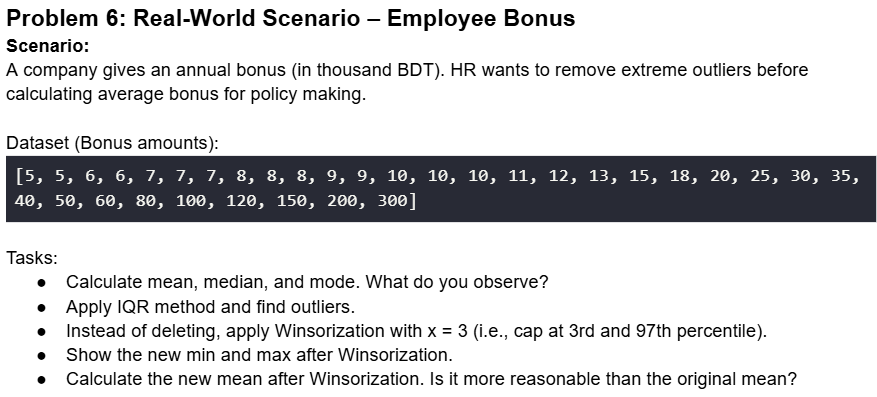

In [32]:
bonus = pd.Series([
    5, 5, 6, 6, 7, 7, 7, 8, 8, 8,
    9, 9, 10, 10, 10, 11, 12, 13, 15, 18,
    20, 25, 30, 35, 40, 50, 60, 80, 100, 120,
    150, 200, 300
])

In [33]:
mean = bonus.mean()
median = bonus.median()
mode = bonus.mode()[0]

print("Mean =", mean)
print("Median =", median)
print("Mode =", mode)

Mean = 42.24242424242424
Median = 12.0
Mode = 7


The mean is much higher than the median because there are some very large bonus values like 100, 120, 150, 200, 300.

In [34]:
Q1 = bonus.quantile(0.25)
Q3 = bonus.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = bonus[(bonus < lower) | (bonus > upper)]

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower)
print("Upper Bound =", upper)
print("Outliers =", outliers.values)

Q1 = 8.0
Q3 = 40.0
IQR = 32.0
Lower Bound = -40.0
Upper Bound = 88.0
Outliers = [100 120 150 200 300]


In [37]:
x = 3
x = x / 100

min_range = bonus.quantile(x)
max_range = bonus.quantile(1 - x)

print("Min range =", min_range)
print("Max range =", max_range)

Min range = 5.0
Max range = 203.99999999999991


In [39]:
winsorized_bonus = bonus.clip(lower=min_range, upper=max_range)

print("New Minimum =", winsorized_bonus.min())
print("New Maximum =", winsorized_bonus.max())

New Minimum = 5
New Maximum = 204


C:\Users\nafis\AppData\Local\Temp\ipykernel_23752\1145967019.py:1: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  winsorized_bonus = bonus.clip(lower=min_range, upper=max_range)


In [40]:
new_mean = winsorized_bonus.mean()

print("Original Mean =", mean)
print("New Mean =", new_mean)

Original Mean = 42.24242424242424
New Mean = 39.333333333333336
